## 1. Simple Linear Regression

Melakukan prediksi score (y) berdasarkan waktu belajar (X) menggunakan dataset Student Score.

In [1]:
import pandas as pd

df_student = pd.read_csv("data/rounded_hours_student_scores.csv")

df_student.head()

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


### Menentukan Variabel X dan y

Menentukan variabel independen (X) dan variabel target (y) dari dataset.
Kolom `Hours` digunakan sebagai variabel X, sedangkan kolom `Scores`
digunakan sebagai variabel y.

In [2]:
X = df_student[["Hours"]]
y = df_student["Scores"]

### Membagi Dataset Menjadi Data Training dan Testing

Dataset dibagi menjadi data training dan data testing dengan perbandingan
80:20. Data training digunakan untuk melatih model, sedangkan data testing
digunakan untuk menguji hasil prediksi model.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

### Melatih Model Simple Linear Regression

Membuat dan melatih model Simple Linear Regression menggunakan data training.
Model digunakan untuk mempelajari hubungan antara waktu belajar dan score.

In [4]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.67]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


### Melakukan Prediksi pada Data Test

Menggunakan model yang telah dilatih untuk memprediksi nilai score
berdasarkan data waktu belajar pada data testing.

In [5]:
y_pred = regressor.predict(X_test)

print(y_pred)

[45.73486532 47.73773562 53.24562895 46.06867704 42.22984229 40.22697199
 47.57082976 53.07872309 48.90607663 44.73343017 40.56078371 42.06293643]


### Menghitung Intercept dan Slope

Menghitung nilai intercept dan slope dari model regresi linear.
Intercept menunjukkan nilai y ketika x bernilai 0, sedangkan slope
menunjukkan perubahan nilai y ketika nilai x bertambah.

In [6]:
a = regressor.intercept_
b = regressor.coef_[0]

print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
print(f"ŷ = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 37.89028997006413
Estimated model slope, b: 1.6690585851433417
ŷ = 37.89 + 1.67x


### Visualisasi Hasil Regresi

Membuat visualisasi untuk melihat hubungan antara waktu belajar dan score.
Data aktual ditampilkan dalam bentuk titik, sedangkan hasil prediksi model
ditampilkan dalam bentuk garis regresi.

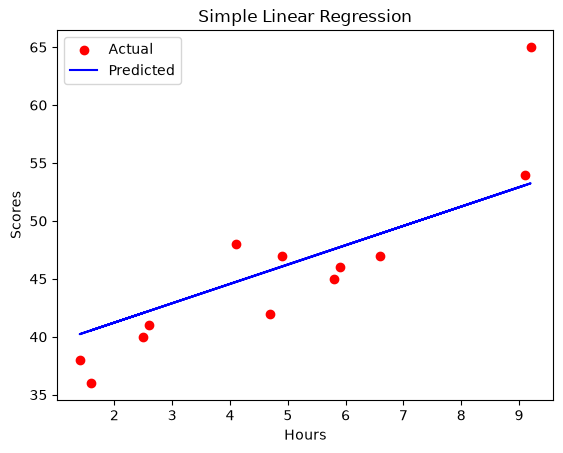

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="red", label="Actual")
plt.plot(X_test, y_pred, color="blue", label="Predicted")

plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

### Evaluasi Model

Melakukan evaluasi terhadap hasil prediksi model menggunakan Mean Squared
Error (MSE) dan R² Score. MSE digunakan untuk mengukur besar kesalahan
prediksi, sedangkan R² Score digunakan untuk mengetahui kemampuan model
dalam menjelaskan variasi pada nilai score.

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 17.440953304881926
R² Score: 0.6886702273580021


### Kesimpulan

Berdasarkan hasil Simple Linear Regression, model digunakan untuk
memprediksi `Scores` berdasarkan `Hours` belajar.

Model regresi menghasilkan hubungan antara waktu belajar dan nilai score,
dengan persamaan regresi:

**ŷ = ...**

Berdasarkan hasil evaluasi, diperoleh nilai:

- **Mean Squared Error (MSE) = ...**
- **R² Score = ...**

Nilai MSE menunjukkan tingkat kesalahan prediksi model, sedangkan R² Score
menunjukkan kemampuan model dalam menjelaskan variasi nilai `Scores`.

## 2. Multiple Linear Regression

Melakukan prediksi `Sales (y)` berdasarkan data marketing berupa `YouTube`,
`Facebook`, dan `Newspaper (X)` menggunakan dataset Marketing Data.

### Import Library dan Dataset

Mengimpor library Pandas dan membaca dataset `Marketing_Data.csv`
untuk melakukan analisis Multiple Linear Regression.

In [9]:
import pandas as pd

df_marketing = pd.read_csv("data/Marketing_Data.csv")

df_marketing.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


### Menentukan Variabel X dan y

Menentukan variabel independen (X) dan variabel target (y) dari dataset.
Kolom `YouTube`, `Facebook`, dan `Newspaper` digunakan sebagai variabel X,
sedangkan kolom `Sales` digunakan sebagai variabel y.

In [11]:
df_marketing.columns

Index(['youtube', 'facebook', 'newspaper', 'sales'], dtype='str')

In [13]:
X2 = df_marketing[["youtube", "facebook", "newspaper"]]
y2 = df_marketing["sales"]

### Membagi Dataset Menjadi Data Training dan Testing

Dataset dibagi menjadi data training dan data testing dengan perbandingan
80:20. Data training digunakan untuk melatih model, sedangkan data testing
digunakan untuk menguji hasil prediksi model.

In [14]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=0
)

### Melatih Model Multiple Linear Regression

Membuat dan melatih model Multiple Linear Regression menggunakan data
training. Model digunakan untuk mempelajari hubungan antara youtube,
facebook, newspaper, dan sales.

In [15]:
from sklearn.linear_model import LinearRegression

regressor2 = LinearRegression()
regressor2.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.18,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['youtube','facebook','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.856
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### Melakukan Prediksi pada Data Test

Menggunakan model yang telah dilatih untuk memprediksi nilai `sales`
berdasarkan data pemasaran pada data testing.

In [16]:
y_pred2 = regressor2.predict(X_test2)

print(y_pred2)

[17.47637032 16.37438329 23.03375348 24.76366742 18.44000541  9.88587684
 27.58148165 28.87880859 23.06393669 19.0636305  13.21803757 14.34999561
  9.23890874 13.14124811 10.24291776 16.2522827  20.0147228  25.73237296
 12.05155149 13.89264368 19.7192218  10.95264453 22.23454235 27.70965086
 20.47231834 11.94972356 19.4677982  15.98774074 23.2733346  20.3406546
 25.5594432  18.45251872  6.66383729 20.57898229 18.94707082]


### Menghitung Intercept dan Koefisien

Menghitung nilai intercept dan koefisien regresi dari masing-masing
variabel predictor, yaitu `youtube`, `facebook`, dan `newspaper`.

In [17]:
a2 = regressor2.intercept_
b1 = regressor2.coef_[0]
b2 = regressor2.coef_[1]
b3 = regressor2.coef_[2]

print("Estimated model intercept, a:", a2)
print("Estimated model coefficient, b1:", b1)
print("Estimated model coefficient, b2:", b2)
print("Estimated model coefficient, b3:", b3)

print(f"ŷ = {a2:.2f} + {b1:.2f}x1 + {b2:.2f}x2 + {b3:.2f}x3")

Estimated model intercept, a: 3.8558434315881644
Estimated model coefficient, b1: 0.04381266146268517
Estimated model coefficient, b2: 0.18387483267122118
Estimated model coefficient, b3: 0.004809634069435289
ŷ = 3.86 + 0.04x1 + 0.18x2 + 0.00x3


### Evaluasi Model

Melakukan evaluasi terhadap hasil prediksi menggunakan Mean Squared Error
(MSE) dan R² Score untuk mengetahui performa model Multiple Linear Regression.

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("Mean Squared Error:", mse2)
print("R² Score:", r2_2)

Mean Squared Error: 3.489778169164483
R² Score: 0.9227472153504573


### Visualisasi Nilai Aktual dan Prediksi

Membandingkan nilai `sales` aktual dengan nilai `sales` hasil prediksi
dari model Multiple Linear Regression menggunakan grafik.

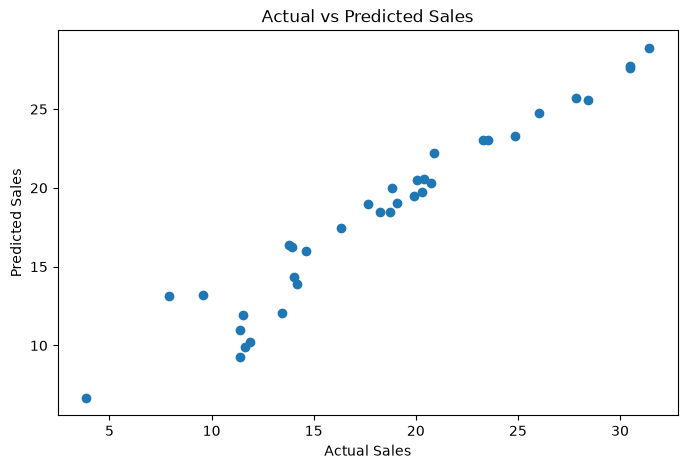

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test2, y_pred2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

### Kesimpulan

Berdasarkan hasil Multiple Linear Regression, model digunakan untuk
memprediksi `sales` berdasarkan variabel `youtube`, `facebook`, dan
`newspaper`.

Model menghasilkan persamaan regresi:

**ŷ = ...**

Berdasarkan hasil evaluasi, diperoleh nilai:

- **Mean Squared Error (MSE) = ...**
- **R² Score = ...**

Nilai MSE menunjukkan tingkat kesalahan prediksi model, sedangkan R² Score
menunjukkan kemampuan model dalam menjelaskan variasi nilai `sales`.